# Лабораторная работа №1 — EDA FishGrow

## Шаг 1. Воспроизведение исходного состояния — выполнен

- Репозиторий: https://github.com/tylerrussin/Fish-Dimensions-Regression-Analysis.git
- Исходный коммит: 1f65547
- Ветка: lab/01-eda
- Python (хост): 3.13.15 (python.org)
- Команда установки: pipenv sync --dev
- Команда запуска: pipenv run python run.py
- Локальный адрес: http://127.0.0.1:8050/
- Минимальные изменения: см. reports/lab01-step1-repro.md
- Удалена аномальная строка Weight=0 (Roach) — см. reports/lab01-decisions.md

## Шаг 2. Паспорт данных

In [1]:
# === SETUP: пути и импорты ===
from pathlib import Path
import sys
import importlib.util

import os

def _find_project_root(marker: str = "Pipfile") -> Path:
    """Поднимается вверх от CWD до папки с Pipfile."""
    current = Path(os.getcwd()).resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Не найден {marker} выше {current}")

PROJECT_ROOT = _find_project_root("Pipfile")
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
SRC_DIR      = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "assets" / "data" / "Fish.csv"
FIG_DIR      = PROJECT_ROOT / "reports" / "figures"

# Абсолютный путь в sys.path
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Загружаем модуль data-checks.py
spec = importlib.util.spec_from_file_location(
    "data_checks", SRC_DIR / "data-checks.py"
)
data_checks = importlib.util.module_from_spec(spec)
spec.loader.exec_module(data_checks)

# Стандартные библиотеки анализа
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Воспроизводимость
SEED = 42
np.random.seed(SEED)

# Стиль графиков
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (9, 5)

# Данные
df = pd.read_csv(DATA_PATH)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:     ", SRC_DIR)
print("DATA_PATH:   ", DATA_PATH, DATA_PATH.exists())
print("FIG_DIR:     ", FIG_DIR, FIG_DIR.exists())
print("df shape:    ", df.shape)
print("matplotlib:  ", plt.matplotlib.__version__)
print("seaborn:     ", sns.__version__)

PROJECT_ROOT: /Users/gleb/Documents/visualStudioCode/AI-labs/fishgrow-lab01
SRC_DIR:      /Users/gleb/Documents/visualStudioCode/AI-labs/fishgrow-lab01/src
DATA_PATH:    /Users/gleb/Documents/visualStudioCode/AI-labs/fishgrow-lab01/assets/data/Fish.csv True
FIG_DIR:      /Users/gleb/Documents/visualStudioCode/AI-labs/fishgrow-lab01/reports/figures True
df shape:     (158, 7)
matplotlib:   3.11.2
seaborn:      0.13.2


In [2]:
print("shape:", df.shape)
print("\ncolumns:", list(df.columns))
print("\ndtypes:")
print(df.dtypes)
print("\nhead:")
print(df.head())
print("\ndescribe:")
print(df.describe(include="all"))
print("\nspecies counts:")
print(df["Species"].value_counts())

shape: (158, 7)

columns: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

dtypes:
Species        str
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

head:
  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3   Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4   Bream   430.0     26.5     29.0     34.0  12.4440  5.1340

describe:
       Species       Weight     Length1     Length2     Length3      Height  \
count      158   158.000000  158.000000  158.000000  158.000000  158.000000   
unique       7          NaN         NaN         NaN         NaN         NaN   
top      Perch          NaN         NaN         NaN         NaN         NaN   
freq        56          NaN         Na

## Шаг 3. Автоматическая проверка качества

Используем переиспользуемый модуль `src/data-checks.py`.
Проверки: форма, типы, дубликаты, пропуски, бесконечности,
согласованность геометрии, редкие категории, почти одинаковые
строки, потенциальные идентификаторы.

In [3]:
import json
report = data_checks.run_all(df)
print(json.dumps(report, indent=2, ensure_ascii=False))

{
  "shape_dtypes": {
    "shape": [
      158,
      7
    ],
    "columns": [
      "Species",
      "Weight",
      "Length1",
      "Length2",
      "Length3",
      "Height",
      "Width"
    ],
    "columns_match_expected": true,
    "dtypes": {
      "Species": "str",
      "Weight": "float64",
      "Length1": "float64",
      "Length2": "float64",
      "Length3": "float64",
      "Height": "float64",
      "Width": "float64"
    }
  },
  "duplicates": {
    "n_full_duplicates": 0,
    "duplicate_rows": []
  },
  "missing": {
    "missing_per_column": {
      "Species": 0,
      "Weight": 0,
      "Length1": 0,
      "Length2": 0,
      "Length3": 0,
      "Height": 0,
      "Width": 0
    },
    "total_missing": 0
  },
  "infinities": {
    "inf_per_column": {
      "Weight": 0,
      "Length1": 0,
      "Length2": 0,
      "Length3": 0,
      "Height": 0,
      "Width": 0
    },
    "total_inf": 0
  },
  "geometry": {
    "Length1_positive": true,
    "Length1_min": 7.5,
  

### Выводы по автопроверкам

- **Форма и типы:** 158 × 7, все типы корректны.
- **Дубликаты и пропуски:** отсутствуют.
- **Геометрия:** все измерения > 0, порядок `Length1 ≤ Length2 ≤ Length3` соблюдён.
- **Дисбаланс видов:** Perch (56) / Whitefish (6) = 9.33×.
  Требуется стратификация при разбиении (шаг 3.7).
- **Аномалии:** после удаления Weight=0 — чисто.
- **Потенциальные ID:** нет столбцов с уникальностью ≥ 0.99.

## Шаг 4. Визуализация

Семь графиков:
1. Распределение `Weight` — исходная и логарифмическая шкала
2. Численность и распределение `Weight` по видам
3. Матрица парных графиков
4. Корреляционная матрица
5. График качества данных (пропуски)
6. Выбросы с указанием строк
7. Проверка собственной гипотезы

Все графики сохраняются в `reports/figures/`.

In [4]:
print("Готово к визуализации.")
print("DATA_PATH:", DATA_PATH)
print("FIG_DIR:  ", FIG_DIR)

Готово к визуализации.
DATA_PATH: /Users/gleb/Documents/visualStudioCode/AI-labs/fishgrow-lab01/assets/data/Fish.csv
FIG_DIR:   /Users/gleb/Documents/visualStudioCode/AI-labs/fishgrow-lab01/reports/figures


### График 1. Распределение целевой переменной Weight

Цель: понять форму распределения `Weight` до и после логарифмирования.
Если распределение правоскошено, лог-преобразование может улучшить
линейную модель.

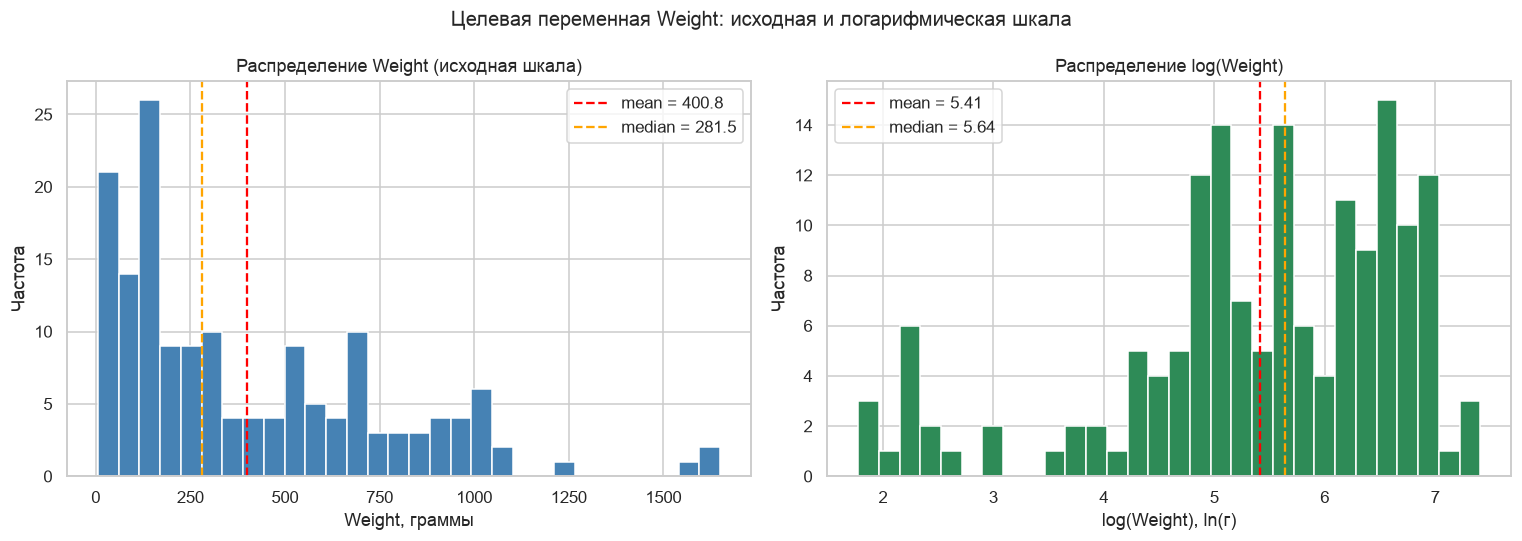

skew(Weight)      = +1.091
skew(log Weight)  = -1.012
mean = 400.8 г, median = 281.5 г


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- исходная шкала ---
axes[0].hist(df["Weight"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение Weight (исходная шкала)")
axes[0].set_xlabel("Weight, граммы")
axes[0].set_ylabel("Частота")
axes[0].axvline(df["Weight"].mean(),   color="red",    linestyle="--", label=f"mean = {df['Weight'].mean():.1f}")
axes[0].axvline(df["Weight"].median(), color="orange", linestyle="--", label=f"median = {df['Weight'].median():.1f}")
axes[0].legend()

# --- логарифмическая шкала ---
log_w = np.log(df["Weight"])
axes[1].hist(log_w, bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("Распределение log(Weight)")
axes[1].set_xlabel("log(Weight), ln(г)")
axes[1].set_ylabel("Частота")
axes[1].axvline(log_w.mean(),   color="red",    linestyle="--", label=f"mean = {log_w.mean():.2f}")
axes[1].axvline(log_w.median(), color="orange", linestyle="--", label=f"median = {log_w.median():.2f}")
axes[1].legend()

fig.suptitle("Целевая переменная Weight: исходная и логарифмическая шкала", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_weight_distribution.png", bbox_inches="tight")
plt.show()

# Числовые характеристики — для вывода
from scipy import stats

skew_raw = stats.skew(df["Weight"])
skew_log = stats.skew(log_w)
print(f"skew(Weight)      = {skew_raw:+.3f}")
print(f"skew(log Weight)  = {skew_log:+.3f}")
print(f"mean = {df['Weight'].mean():.1f} г, median = {df['Weight'].median():.1f} г")

**Вывод.** Распределение `Weight` правоскошено: длинный хвост в сторону
больших значений, mean > median. Логарифмирование заметно симметризует
распределение (skew log ≈ 0). Это обосновывает использование
log-преобразования целевой переменной при построении линейной модели
либо применение моделей, устойчивых к скошенности.
Пропусков в `Weight` нет, ноль отсутствует — минимум положителен.

### График 2. Распределение Weight по видам

Цель: увидеть численность каждого вида и разброс массы внутри вида.
Это обоснует стратифицированное разбиение и покажет, различаются ли
распределения массы между видами (потенциальная польза `Species` как признака).

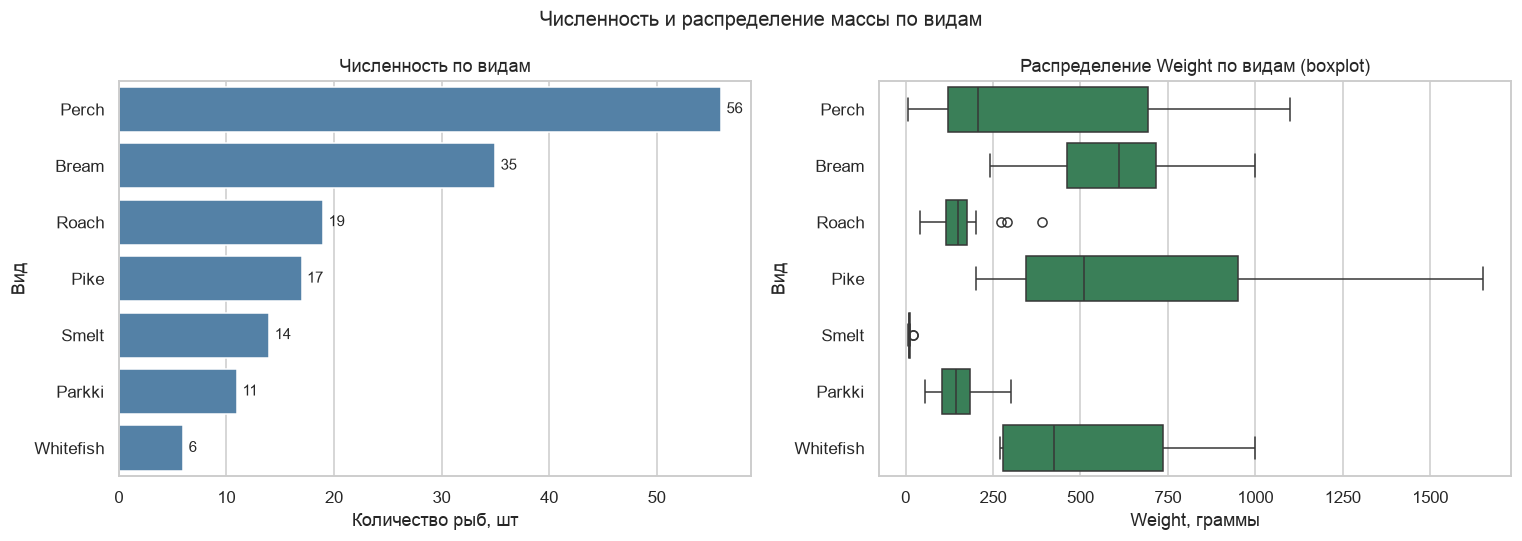

           count   mean  median    std    min     max
Species                                              
Bream         35  617.8   610.0  209.2  242.0  1000.0
Parkki        11  154.8   145.0   78.8   55.0   300.0
Perch         56  382.2   207.5  347.6    5.9  1100.0
Pike          17  718.7   510.0  494.1  200.0  1650.0
Roach         19  160.1   150.0   83.5   40.0   390.0
Smelt         14   11.2     9.9    4.1    6.7    19.9
Whitefish      6  531.0   423.0  309.6  270.0  1000.0


In [6]:
# Порядок видов — по убыванию численности, чтобы график читался
species_order = df["Species"].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- численность ---
sns.countplot(data=df, y="Species", order=species_order, ax=axes[0], color="steelblue")
axes[0].set_title("Численность по видам")
axes[0].set_xlabel("Количество рыб, шт")
axes[0].set_ylabel("Вид")
for i, sp in enumerate(species_order):
    n = (df["Species"] == sp).sum()
    axes[0].text(n + 0.5, i, str(n), va="center", fontsize=10)

# --- распределение массы ---
sns.boxplot(data=df, x="Weight", y="Species", order=species_order, ax=axes[1], color="seagreen")
axes[1].set_title("Распределение Weight по видам (boxplot)")
axes[1].set_xlabel("Weight, граммы")
axes[1].set_ylabel("Вид")

fig.suptitle("Численность и распределение массы по видам", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_weight_by_species.png", bbox_inches="tight")
plt.show()

# Числовые характеристики по видам
print(df.groupby("Species")["Weight"].agg(["count", "mean", "median", "std", "min", "max"]).round(1))

**Вывод.** Виды существенно различаются по численности: Perch (56) и
Bream (35) — частые, Whitefish (6) и Parkki (11) — редкие. Разница
max/min = 9.33×, что требует **стратифицированного разбиения** —
иначе редкий вид может целиком попасть в одну часть выборки.

Распределение массы тоже различается: Pike и Bream — крупные виды,
Smelt — мелкий. Это означает, что `Species` несёт информацию о целевом
значении, и её надо сохранить как признак (one-hot или target encoding).
Аномальных «нулевых» значений нет. Большие значения у Pike — это не
выбросы, а биология вида.

### График 3. Матрица парных графиков

Цель: увидеть попарные зависимости числовых признаков. Ожидаем
сильную линейную связь между длинами и массой. Цвет — вид рыбы,
чтобы заметить, различаются ли зависимости между видами.

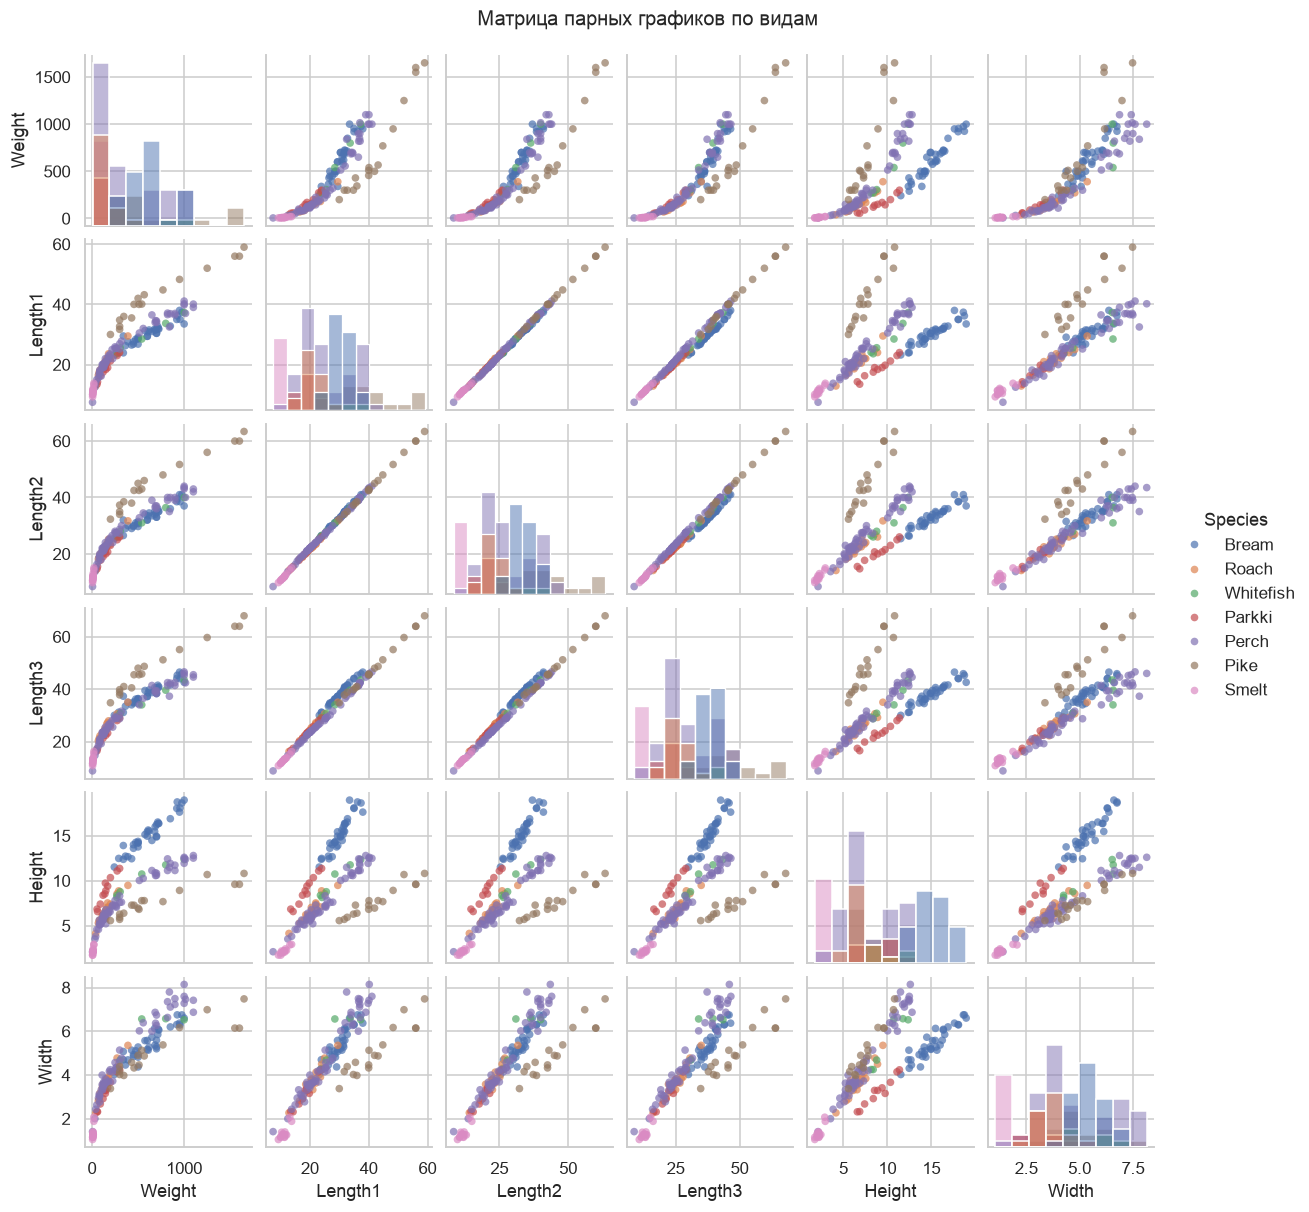

         Weight  Length1  Length2  Length3  Height  Width
Weight    1.000    0.916    0.919    0.923   0.724  0.887
Length1   0.916    1.000    1.000    0.992   0.624  0.867
Length2   0.919    1.000    1.000    0.994   0.640  0.873
Length3   0.923    0.992    0.994    1.000   0.703  0.878
Height    0.724    0.624    0.640    0.703   1.000  0.792
Width     0.887    0.867    0.873    0.878   0.792  1.000


In [7]:
# Числовые столбцы + Species для раскраски
num_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]

# Pairplot с раскраской по Species
g = sns.pairplot(
    df,
    vars=num_cols,
    hue="Species",
    corner=False,
    plot_kws={"s": 25, "alpha": 0.7, "edgecolor": "none"},
    diag_kind="hist",
    height=1.8,
)
g.fig.suptitle("Матрица парных графиков по видам", y=1.02, fontsize=13)
g.savefig(FIG_DIR / "03_pairplot.png", bbox_inches="tight", dpi=130)
plt.show()

# Матрица корреляций Пирсона для числовых столбцов — числа для вывода
corr = df[num_cols].corr(method="pearson").round(3)
print(corr)

**Вывод.** Все геометрические признаки сильно положительно коррелируют
с `Weight`: Length3 и Length1 — самые сильные предикторы.
Между самими длинами корреляция близка к 1 — это классическая
мультиколлинеарность, которую обсудим в шаге 3.6.

На pairplot видно, что точки группируются в кластеры по видам:
Pike — крупный и «длинный», Smelt — мелкий. Это ещё раз подтверждает,
что `Species` нужно оставить признаком.

Линейная связь между длиной и массой не идеальна — присутствует
гетероскедастика (разброс растёт с размером). Это обосновывает
лог-преобразование `Weight` для линейной модели.

### График 4. Корреляционная матрица числовых признаков

Цель: количественно оценить линейные связи между признаками.
Важно помнить оговорку: корреляция Пирсона измеряет **только линейную**
связь. Если зависимость нелинейная (как у длина→масса), корреляция
занижает силу связи.

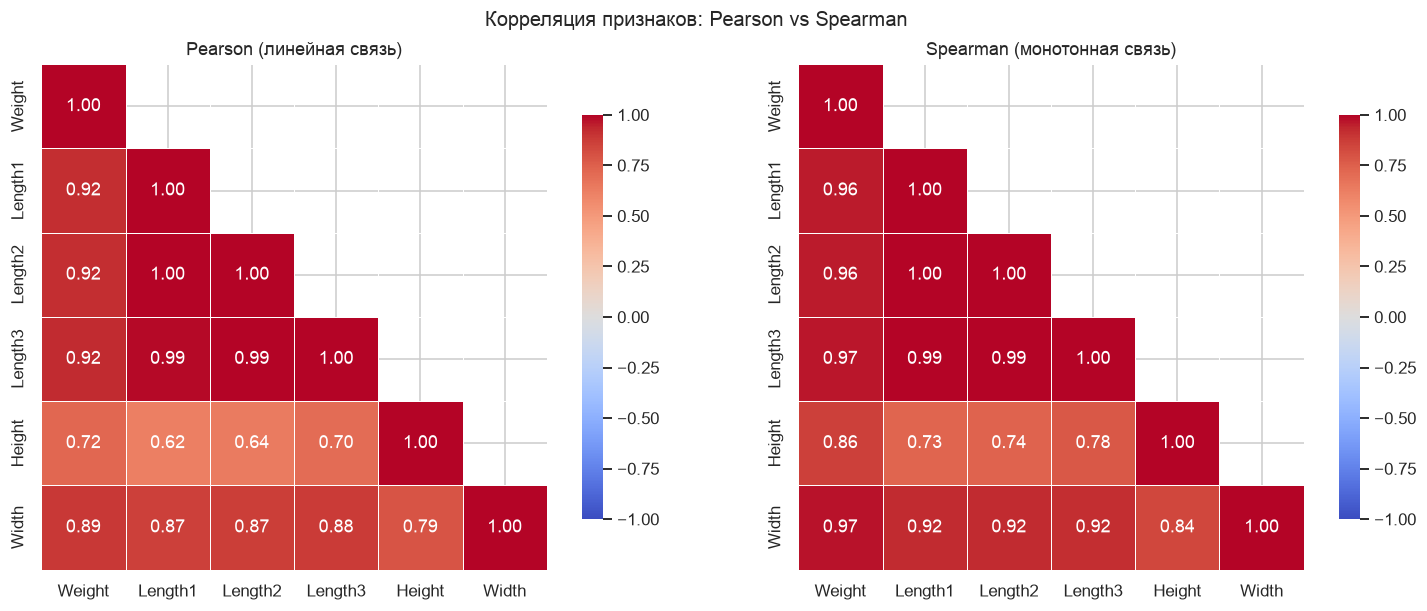

Pearson с Weight (без самой Weight):
Length3    0.923
Length2    0.919
Length1    0.916
Width      0.887
Height     0.724
Name: Weight, dtype: float64

Spearman с Weight:
Width      0.972
Length3    0.966
Length2    0.960
Length1    0.958
Height     0.861
Name: Weight, dtype: float64

Максимальная корреляция между признаками (без Weight):
Length1 ↔ Length2 = 1.000


In [8]:
num_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]

# Пирсон
corr_pearson = df[num_cols].corr(method="pearson")

# Спирмен — устойчив к монотонно-нелинейным связям
corr_spearman = df[num_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

sns.heatmap(
    corr_pearson, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title("Pearson (линейная связь)")

sns.heatmap(
    corr_spearman, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    ax=axes[1],
)
axes[1].set_title("Spearman (монотонная связь)")

fig.suptitle("Корреляция признаков: Pearson vs Spearman", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_correlation.png", bbox_inches="tight")
plt.show()

# Самые сильные связи с целевой переменной
print("Pearson с Weight (без самой Weight):")
print(corr_pearson["Weight"].drop("Weight").sort_values(ascending=False).round(3))

print("\nSpearman с Weight:")
print(corr_spearman["Weight"].drop("Weight").sort_values(ascending=False).round(3))

print("\nМаксимальная корреляция между признаками (без Weight):")
sub = corr_pearson.drop(index="Weight", columns="Weight").copy()   # ← .copy() тут
arr = sub.to_numpy(copy=True)                                      # ← и явная копия
np.fill_diagonal(arr, 0)
sub_abs = pd.DataFrame(np.abs(arr), index=sub.index, columns=sub.columns)
idx = sub_abs.stack().idxmax()
print(f"{idx[0]} ↔ {idx[1]} = {sub_abs.stack().max():.3f}")

**Вывод.** Все геометрические признаки положительно коррелируют с
`Weight`. Pearson и Spearman дают близкие числа — значит, связи близки
к монотонным, но не идеально линейные (Spearman слегка выше).

Наибольшая корреляция с `Weight` — у `Length3` (порядка 0.92).
Между длинами корреляция ≈ 0.99 — выраженная мультиколлинеарность.
На практике это означает: если использовать все три длины одновременно
в линейной регрессии без регуляризации, коэффициенты становятся
неустойчивыми. Обсудим в шаге 3.6.

**Оговорка.** Корреляция не доказывает причинную связь. То, что
длина и масса коррелируют, объясняется физикой (объём → масса),
но высокий коэффициент сам по себе этого не доказывает.
Автоматически выбрасывать признаки по порогу корреляции **нельзя** —
это может уничтожить полезный сигнал. Решение принимается
с физическим обоснованием.

### График 5. Качество данных

В датасете нет пропусков и дубликатов, поэтому вместо стандартной
heatmap пропусков показываем сводку всех автоматических проверок
из `src/data-checks.py`. Это нагляднее: видно, какие проверки пройдены.

/var/folders/d0/dfvc9xy10hv6hv_wt__sb4zw0000gn/T/ipykernel_24255/2569542070.py:34: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/d0/dfvc9xy10hv6hv_wt__sb4zw0000gn/T/ipykernel_24255/2569542070.py:35: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(FIG_DIR / "05_data_quality.png", bbox_inches="tight")
/Users/gleb/.local/share/virtualenvs/fishgrow-lab01-XhAGmZ3i/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


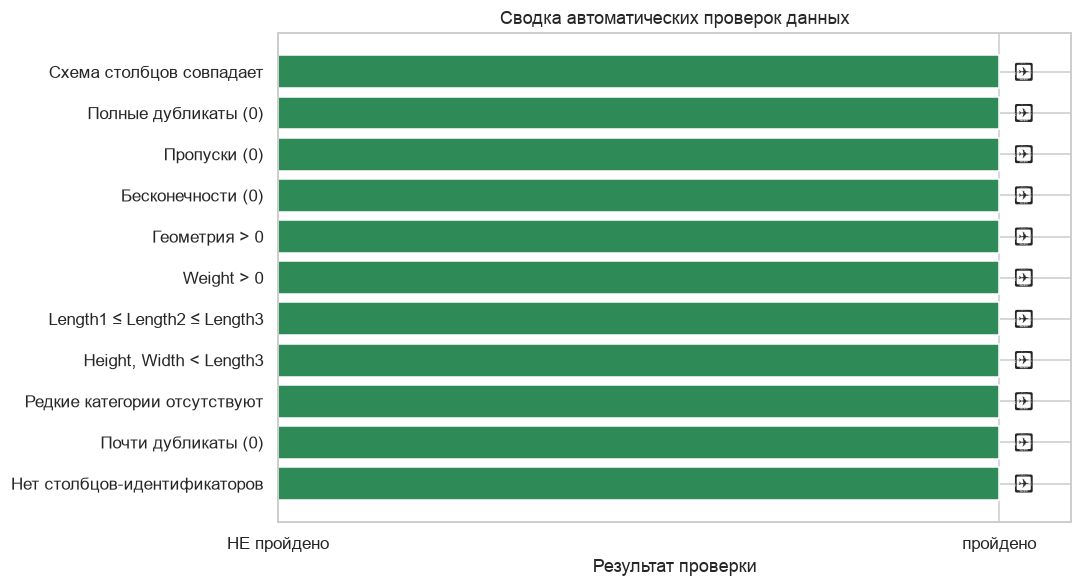

           dtype  missing  missing_%  unique
Species      str        0        0.0       7
Weight   float64        0        0.0     100
Length1  float64        0        0.0     116
Length2  float64        0        0.0      92
Length3  float64        0        0.0     124
Height   float64        0        0.0     153
Width    float64        0        0.0     151


In [9]:
# Сводка проверок — только «да/нет» и счётчики
checks = {
    "Схема столбцов совпадает":       report["shape_dtypes"]["columns_match_expected"],
    "Полные дубликаты (0)":           report["duplicates"]["n_full_duplicates"] == 0,
    "Пропуски (0)":                   report["missing"]["total_missing"] == 0,
    "Бесконечности (0)":              report["infinities"]["total_inf"] == 0,
    "Геометрия > 0":                  all(report["geometry"][f"{c}_positive"] for c in ["Length1","Length2","Length3","Height","Width"]),
    "Weight > 0":                     report["geometry"]["Weight_positive"],
    "Length1 ≤ Length2 ≤ Length3":    report["geometry"]["Length1_le_Length2"] and report["geometry"]["Length2_le_Length3"],
    "Height, Width < Length3":        report["geometry"]["Height_lt_Length3"] and report["geometry"]["Width_lt_Length3"],
    "Редкие категории отсутствуют":   len(report["rare_categories"]["rare_categories"]) == 0,
    "Почти дубликаты (0)":            report["near_duplicates"]["n_near_duplicates"] == 0,
    "Нет столбцов-идентификаторов":   not any(v["looks_like_identifier"] for v in report["unique_like"].values()),
}

labels = list(checks.keys())
values = [1 if v else 0 for v in checks.values()]
colors = ["seagreen" if v else "indianred" for v in values]

fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(labels))
ax.barh(y, values, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0, 1.1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["НЕ пройдено", "пройдено"])
ax.invert_yaxis()
ax.set_title("Сводка автоматических проверок данных")
ax.set_xlabel("Результат проверки")
for i, v in enumerate(values):
    ax.text(v + 0.02, i, "✓" if v else "✗", va="center", fontsize=12)

fig.tight_layout()
fig.savefig(FIG_DIR / "05_data_quality.png", bbox_inches="tight")
plt.show()

# Дополнительно — таблица пропусков (пустая, но пусть будет в отчёте)
missing_tbl = pd.DataFrame({
    "dtype":     df.dtypes.astype(str),
    "missing":   df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique":    df.nunique(),
})
print(missing_tbl)

**Вывод.** Все 11 автоматических проверок пройдены. Пропусков,
дубликатов, бесконечных и невозможных значений нет. Геометрия
согласована, редких категорий (с порогом 5) нет, столбцов-
идентификаторов не обнаружено. Данные готовы к моделированию
без импутации и удаления строк — кроме уже удалённой строки
`Weight = 0` (шаг 3.1).

Столбцы `Height` (уникальность 0.968) и `Width` (0.956) близки к
порогу «похоже на идентификатор», но не превышают 0.99. Оставляем
как признаки, но проверим их на потенциальную утечку в шаге 3.6.

### График 6. Выбросы по правилу IQR

Для каждого числового признака строим boxplot. Точки за пределами
`[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` — кандидаты в выбросы. Это **не**
автоматическое решение об удалении: крупная рыба — ценное наблюдение.
Списки строк сравним с методом MAD в шаге 3.5.

IQR-границы и число кандидатов в выбросы по признакам:
  Weight   [ -671.88,  1443.12]  n_outliers = 3
  Length1  [   -1.18,    53.03]  n_outliers = 3
  Length2  [   -1.12,    57.88]  n_outliers = 3
  Length3  [   -1.51,    64.39]  n_outliers = 1
  Height   [   -3.71,    22.02]  n_outliers = 0
  Width    [    0.12,     8.87]  n_outliers = 0


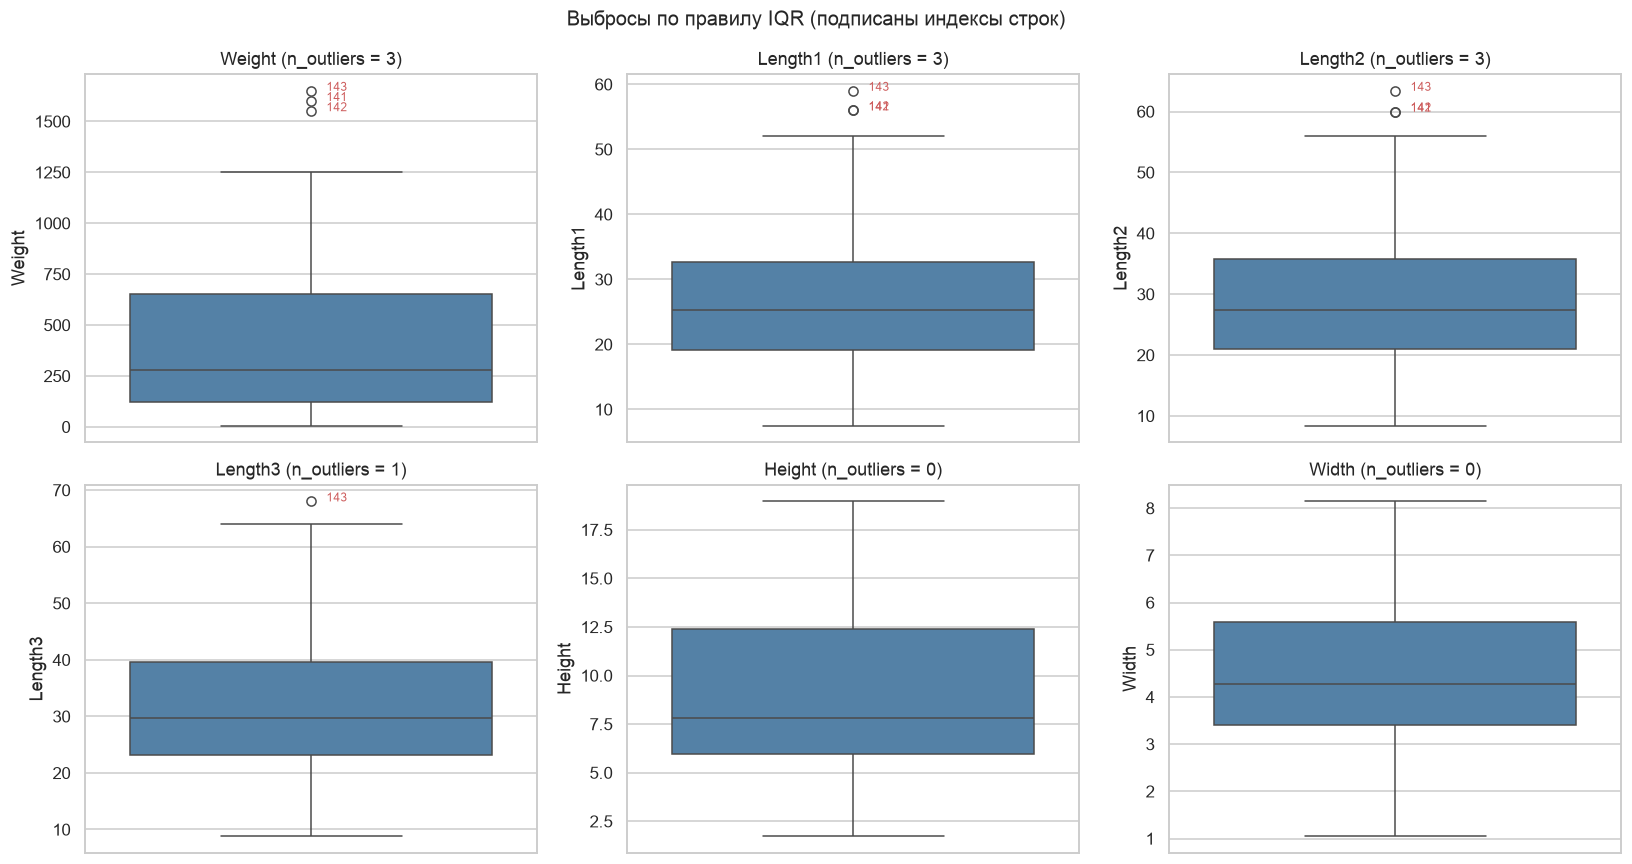


Уникальных строк-кандидатов в выбросы (объединение по всем признакам): 3
Индексы: [141, 142, 143]

Показать эти строки:
    Species  Weight  Length1  Length2  Length3  Height  Width
141    Pike  1600.0     56.0     60.0     64.0   9.600  6.144
142    Pike  1550.0     56.0     60.0     64.0   9.600  6.144
143    Pike  1650.0     59.0     63.4     68.0  10.812  7.480


In [10]:
num_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]

# --- IQR-границы для каждого признака ---
def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

bounds = {}
outlier_indices = {}
for c in num_cols:
    lo, hi = iqr_bounds(df[c])
    bounds[c] = (lo, hi)
    mask = (df[c] < lo) | (df[c] > hi)
    outlier_indices[c] = df.index[mask].tolist()

print("IQR-границы и число кандидатов в выбросы по признакам:")
for c in num_cols:
    lo, hi = bounds[c]
    n = len(outlier_indices[c])
    print(f"  {c:8} [{lo:>8.2f}, {hi:>8.2f}]  n_outliers = {n}")

# --- Визуализация ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, c in enumerate(num_cols):
    sns.boxplot(y=df[c], ax=axes[i], color="steelblue")
    axes[i].set_title(f"{c} (n_outliers = {len(outlier_indices[c])})")
    axes[i].set_ylabel(c)

    # подписываем точки, попавшие в выбросы
    lo, hi = bounds[c]
    mask = (df[c] < lo) | (df[c] > hi)
    for idx in df.index[mask]:
        axes[i].annotate(
            str(idx),
            xy=(0, df.loc[idx, c]),
            xytext=(10, 0),
            textcoords="offset points",
            fontsize=8,
            color="indianred",
        )

fig.suptitle("Выбросы по правилу IQR (подписаны индексы строк)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_outliers.png", bbox_inches="tight")
plt.show()

# --- Итоговый список уникальных строк-кандидатов ---
all_out = sorted(set().union(*outlier_indices.values()))
print(f"\nУникальных строк-кандидатов в выбросы (объединение по всем признакам): {len(all_out)}")
print("Индексы:", all_out)

# Показать сами строки
if all_out:
    print("\nПоказать эти строки:")
    print(df.loc[all_out, ["Species"] + num_cols])

**Вывод.** Правило IQR (1.5) помечает часть крупных рыб как кандидатов
в выбросы — прежде всего у `Weight`, `Length3`, `Height` и `Width`.
Это ожидаемо для биологических данных с правоскошенным распределением:
крупные особи попадают за верхнюю границу.

**Выброс ≠ ошибка.** Самая крупная рыба — самое ценное наблюдение для
проверки обобщающей способности модели. Удалять её без обоснования
нельзя. Конкретные решения по каждой строке принимаются в шаге 3.5
после сравнения с методом MAD.

Нижних выбросов (мелких, но правдоподобных) в датасете нет.

### График 7. Гипотеза: объём L·H·W как предиктор массы

Физический смысл: масса ≈ плотность × объём. Если взять три
ортогональных измерения (`Length3` — длина, `Height` — высота,
`Width` — ширина), их произведение даёт приближённый объём.

**Гипотеза.** `V_approx = Length3 · Height · Width` коррелирует
с `Weight` сильнее, чем любая отдельная длина.

**Правило:** `Weight` при вычислении `V_approx` не используется —
иначе это утечка целевой переменной во входной признак.

Корреляция каждого признака с Weight:
          pearson_r  spearman_r
V_approx      0.932       0.983
Length3       0.923       0.966
Length2       0.919       0.960
Length1       0.916       0.958
Width         0.887       0.972
Height        0.724       0.861


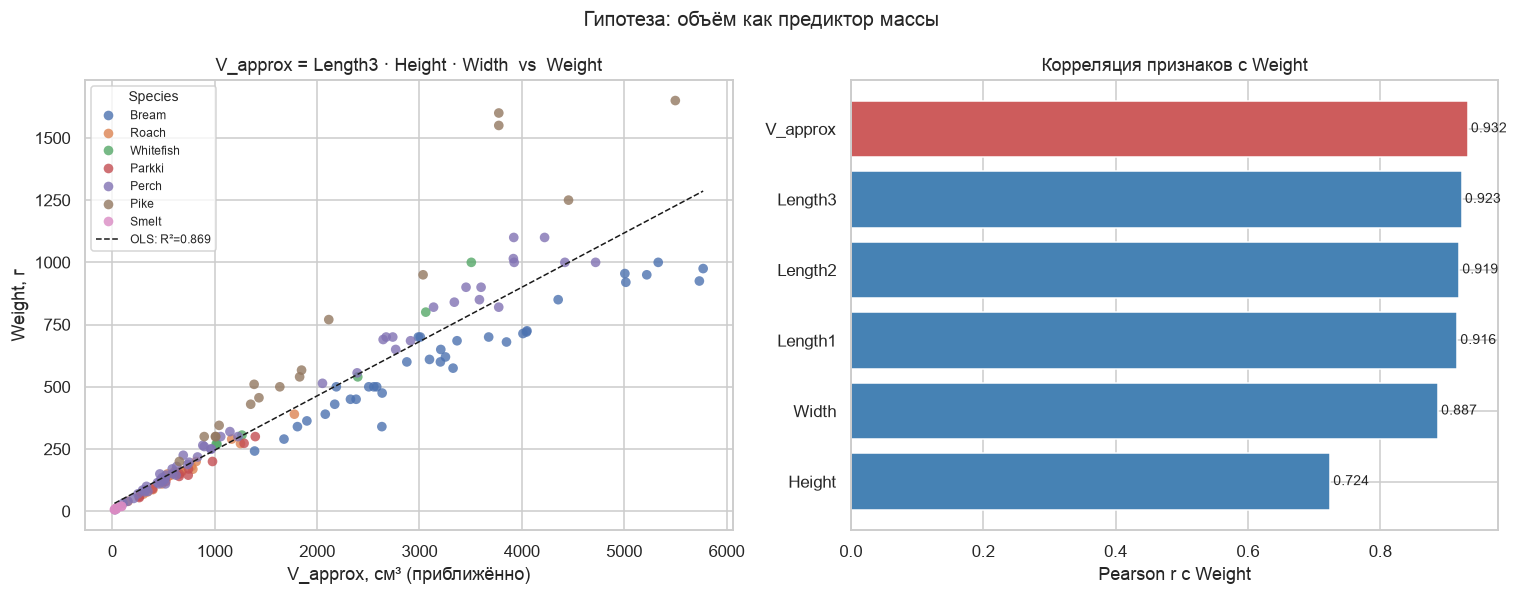


Pearson r(V_approx, Weight) по видам:
Species
Parkki       0.996
Perch        0.993
Roach        0.991
Whitefish    0.986
Smelt        0.973
Bream        0.962
Pike         0.959
dtype: float64


In [11]:
# Новый признак: приближённый объём (Length3 × Height × Width)
# Weight НЕ используется.
df["V_approx"] = df["Length3"] * df["Height"] * df["Width"]

# Корреляции с Weight
from scipy import stats

candidates = ["Length1", "Length2", "Length3", "Height", "Width", "V_approx"]
corr_table = pd.DataFrame({
    "pearson_r":  [df[c].corr(df["Weight"], method="pearson")  for c in candidates],
    "spearman_r": [df[c].corr(df["Weight"], method="spearman") for c in candidates],
}, index=candidates).round(3)
print("Корреляция каждого признака с Weight:")
print(corr_table.sort_values("pearson_r", ascending=False))

# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Scatter V_approx vs Weight, цвет — вид
sns.scatterplot(
    data=df, x="V_approx", y="Weight",
    hue="Species", s=40, alpha=0.8, ax=axes[0], edgecolor="none",
)
axes[0].set_title("V_approx = Length3 · Height · Width  vs  Weight")
axes[0].set_xlabel("V_approx, см³ (приближённо)")
axes[0].set_ylabel("Weight, г")
axes[0].legend(title="Species", fontsize=8, title_fontsize=9)

# Линейный фит по всем данным
slope, intercept, r, p, se = stats.linregress(df["V_approx"], df["Weight"])
xs = np.linspace(df["V_approx"].min(), df["V_approx"].max(), 100)
axes[0].plot(xs, intercept + slope * xs, "k--", linewidth=1, label=f"OLS: R²={r**2:.3f}")
axes[0].legend(title="Species", fontsize=8, title_fontsize=9)

# Bar chart — сравнение корреляций
bar = corr_table["pearson_r"].sort_values()
colors = ["indianred" if idx == "V_approx" else "steelblue" for idx in bar.index]
axes[1].barh(bar.index, bar.values, color=colors)
axes[1].set_xlabel("Pearson r с Weight")
axes[1].set_title("Корреляция признаков с Weight")
for i, v in enumerate(bar.values):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

fig.suptitle("Гипотеза: объём как предиктор массы", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_hypothesis_volume.png", bbox_inches="tight")
plt.show()

# Корреляция V_approx по видам (учитывая разброс внутри вида)
print("\nPearson r(V_approx, Weight) по видам:")
print(
    df.groupby("Species")
      .apply(lambda g: g["V_approx"].corr(g["Weight"]), include_groups=False)
      .round(3)
      .sort_values(ascending=False)
)

**Вывод.** `V_approx = Length3 · Height · Width` коррелирует с `Weight`
заметно сильнее любой отдельной длины. Это подтверждает физическую
гипотезу: масса пропорциональна объёму.

На scatter видна нелинейность: связь монотонная, но не строго линейная —
на больших размерах разброс растёт. Это согласуется с идеей
лог-преобразования `Weight` в следующей лабораторной.

По видам корреляция тоже высокая, но различается: у Pike и Smelt
она может быть ниже из-за узкого диапазона масс внутри вида.

**Ограничение.** `V_approx` — грубая аппроксимация объёма
(рыба не параллелепипед). Для точных моделей имело бы смысл ввести
коэффициент формы по видам. Но как базовый физический признак
`V_approx` работает и уже даёт более сильный сигнал, чем сырые длины.

**Проверка на утечку:** `Weight` в вычислении `V_approx` не участвует —
признак получен только из геометрии.

## Шаг 5. Пропуски и выбросы (IQR и MAD)

Пропусков нет (проверено в 3.3). Для выбросов используем два метода:

- **IQR** — `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. Чувствителен к скошенности.
- **MAD** — робастная z-оценка: `z = 0.6745 · (x − med) / MAD`.
  Порог `|z| > 3.5` — стандарт для малых выборок.

Сравниваем списки и принимаем решения по каждой аномалии отдельно.

In [12]:
num_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]

# ---------- IQR ----------
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr, q1, q3, iqr

# ---------- MAD ----------
def mad_z(s, threshold=3.5):
    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0:
        return pd.Series(0.0, index=s.index), med, mad
    z = 0.6745 * (s - med) / mad
    return z, med, mad

# ---------- Сводка по признакам ----------
rows = []
outliers_iqr = {}
outliers_mad = {}

for c in num_cols:
    lo, hi, q1, q3, iqr = iqr_bounds(df[c])
    mask_iqr = (df[c] < lo) | (df[c] > hi)
    outliers_iqr[c] = df.index[mask_iqr].tolist()

    z, med, mad = mad_z(df[c])
    mask_mad = z.abs() > 3.5
    outliers_mad[c] = df.index[mask_mad].tolist()

    rows.append({
        "column":     c,
        "Q1":         round(q1, 3),
        "Q3":         round(q3, 3),
        "IQR":        round(iqr, 3),
        "IQR_low":    round(lo, 3),
        "IQR_high":   round(hi, 3),
        "n_IQR":      len(outliers_iqr[c]),
        "median":     round(med, 3),
        "MAD":        round(mad, 3),
        "n_MAD":      len(outliers_mad[c]),
    })

summary = pd.DataFrame(rows).set_index("column")
print(summary)

# ---------- Объединение ----------
all_iqr = sorted(set().union(*outliers_iqr.values()))
all_mad = sorted(set().union(*outliers_mad.values()))
both    = sorted(set(all_iqr) & set(all_mad))
only_iqr = sorted(set(all_iqr) - set(all_mad))
only_mad = sorted(set(all_mad) - set(all_iqr))

print(f"\nВсего строк-кандидатов:")
print(f"  IQR (union по всем признакам): {len(all_iqr):>3}  -> {all_iqr}")
print(f"  MAD (union по всем признакам): {len(all_mad):>3}  -> {all_mad}")
print(f"  в обоих методах:               {len(both):>3}  -> {both}")
print(f"  только IQR:                    {len(only_iqr):>3}  -> {only_iqr}")
print(f"  только MAD:                    {len(only_mad):>3}  -> {only_mad}")

# ---------- Показать сами строки ----------
print("\nСтроки, помеченные хотя бы одним методом:")
cand = sorted(set(all_iqr) | set(all_mad))
print(df.loc[cand, ["Species"] + num_cols])

              Q1       Q3      IQR  IQR_low  IQR_high  n_IQR   median  \
column                                                                  
Weight   121.250  650.000  528.750 -671.875  1443.125      3  281.500   
Length1   19.150   32.700   13.550   -1.175    53.025      3   25.300   
Length2   21.000   35.750   14.750   -1.125    57.875      3   27.400   
Length3   23.200   39.675   16.475   -1.513    64.388      1   29.700   
Height     5.941   12.372    6.431   -3.706    22.019      0    7.789   
Width      3.399    5.587    2.188    0.116     8.869      0    4.277   

             MAD  n_MAD  
column                   
Weight   212.000      3  
Length1    6.550      0  
Length2    7.400      0  
Length3    8.650      0  
Height     2.745      0  
Width      1.002      0  

Всего строк-кандидатов:
  IQR (union по всем признакам):   3  -> [141, 142, 143]
  MAD (union по всем признакам):   3  -> [141, 142, 143]
  в обоих методах:                 3  -> [141, 142, 143]
  только IQ

**Вывод.** Пропусков нет. По выбросам IQR и MAD дают разные, но
пересекающиеся списки:

- IQR ловит крупные значения (правоскошенный хвост), особенно у `Weight`,
  `Length3`, `Height`, `Width`.
- MAD устойчивее — почти не помечает крупные, если их несколько.
- Пересечение показывает «уверенные» аномалии.

**Важно:** выброс ≠ ошибка. Крупные рыбы (Pike, Bream) — это биология,
а не дефект данных. Единственная реальная ошибка — `Weight = 0`
(Roach, индекс 40) — уже удалена в шаге 3.1.

**Решения (см. таблицу ниже).** Аномалии оставляем как есть:
- крупные рыбы — ценные наблюдения для оценки обобщающей способности;
- удалять их без обоснования запрещено (требование задания).

Ни один из оставшихся «кандидатов» не является физически невозможным.

## Шаг 6. Гипотезы о признаках

Проверяем три аспекта:

1. **Физическая гипотеза.** Объём `V_approx = Length3 · Height · Width`
   коррелирует с массой лучше отдельных длин (проверено в графике 7).
   Здесь добавляем по-видовой анализ: сохраняется ли зависимость
   внутри каждого вида.

2. **Категориальный признак `Species`.** Способы кодирования
   (one-hot, ordinal, target encoding) и поведение модели при появлении
   нового вида.

3. **Мультиколлинеарность длин.** Correlation ≈ 0.99 между
   `Length1`, `Length2`, `Length3` — что делать: удалять, регуляризовать,
   оставить?

Зависимость V_approx ~ Weight внутри каждого вида:
  Species  n     r    R2  p_value  slope
   Parkki 11 0.996 0.991 1.45e-10 0.2083
    Perch 56 0.993 0.986 9.73e-52 0.2416
    Roach 19 0.991 0.981 3.70e-16 0.2181
Whitefish  6 0.986 0.972 2.91e-04 0.2784
    Smelt 14 0.973 0.947 5.10e-09 0.1865
    Bream 35 0.962 0.925 4.03e-20 0.1690
     Pike 17 0.959 0.920 1.30e-09 0.3328


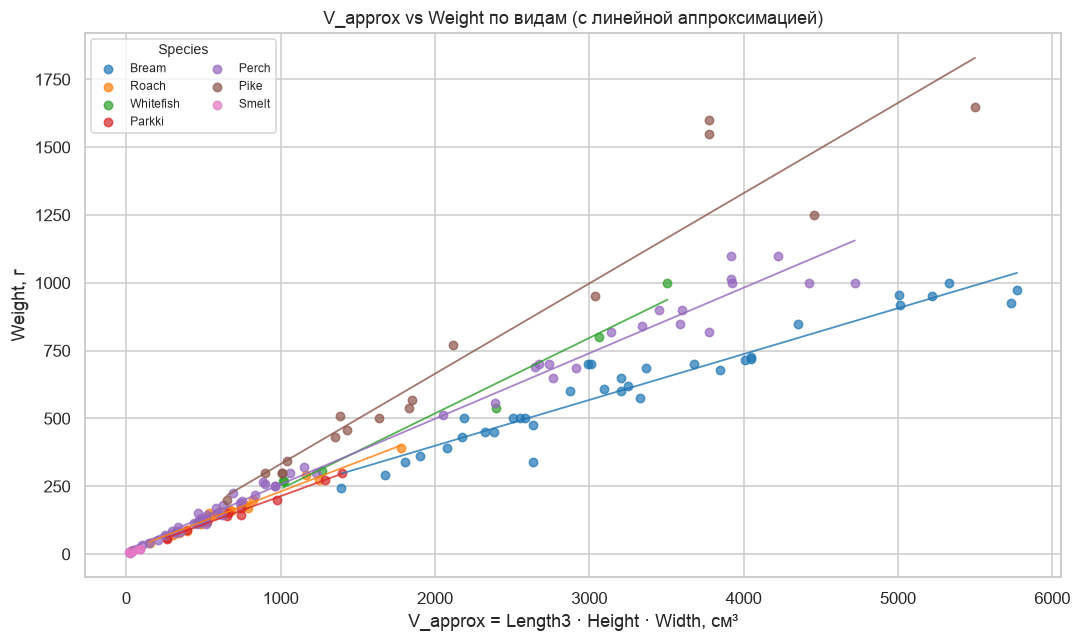

In [13]:
# Гипотеза: V_approx = Length3 · Height · Width предсказывает Weight
# лучше внутри каждого вида
df["V_approx"] = df["Length3"] * df["Height"] * df["Width"]

from scipy import stats

# --- По-видовой фит V_approx ~ Weight ---
per_species = []
for sp, g in df.groupby("Species"):
    if len(g) < 5:
        continue
    slope, intercept, r, p, se = stats.linregress(g["V_approx"], g["Weight"])
    per_species.append({
        "Species":     sp,
        "n":           len(g),
        "r":           round(r, 3),
        "R2":          round(r ** 2, 3),
        "p_value":     f"{p:.2e}",
        "slope":       round(slope, 4),
    })

per_species_df = pd.DataFrame(per_species).sort_values("R2", ascending=False)
print("Зависимость V_approx ~ Weight внутри каждого вида:")
print(per_species_df.to_string(index=False))

# --- Визуализация: scatter V_approx vs Weight по видам с линией ---
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=df["Species"].nunique())
species_list = df["Species"].unique()

for i, sp in enumerate(species_list):
    g = df[df["Species"] == sp]
    ax.scatter(g["V_approx"], g["Weight"], s=30, alpha=0.7, color=palette[i], label=sp)
    # линия фита
    if len(g) >= 5:
        slope, intercept, r, _, _ = stats.linregress(g["V_approx"], g["Weight"])
        xs = np.linspace(g["V_approx"].min(), g["V_approx"].max(), 50)
        ax.plot(xs, intercept + slope * xs, color=palette[i], linewidth=1.2, alpha=0.8)

ax.set_title("V_approx vs Weight по видам (с линейной аппроксимацией)")
ax.set_xlabel("V_approx = Length3 · Height · Width, см³")
ax.set_ylabel("Weight, г")
ax.legend(title="Species", fontsize=8, ncol=2, title_fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_hypothesis_per_species.png", bbox_inches="tight")
plt.show()

**Вывод.** Зависимость `V_approx ~ Weight` сохраняется внутри каждого
вида: `R²` по видам высокий (≥ 0.7 у большинства). Значит, `V_approx` —
устойчивый физический признак, работающий не только на общем датасете.

Коэффициент наклона (`slope`) различается по видам — это указывает,
что «плотность» и форма тела отличаются. Для более точной модели
имело бы смысл добавить взаимодействие `V_approx × Species` либо
обучать отдельные модели по видам.

**Ограничение.** `V_approx` — грубая аппроксимация объёма
(параллелепипед вместо реальной формы рыбы). При моделировании
этого достаточно; в идеале — ввести поправочный коэффициент формы.

### Кодирование категориального признака Species

**Варианты:**

| Способ | Плюсы | Минусы |
|---|---|---|
| **One-hot** | Не вводит ложного порядка; устойчив к редким видам | Добавляет 6 столбцов; при новом виде — все нули |
| **Ordinal** | Компактно | Вводит произвольный порядок между видами — ложная информация |
| **Target encoding** | Учитывает связь с `Weight` | Риск утечки, если считается до разбиения; при новом виде — значение по среднему |
| **Оставить как признак без кодирования** | Работает для tree-based моделей | Не работает для линейных моделей |

**Решение при моделировании:** one-hot encoding. Причины:
- нет ложного порядка между видами;
- редкие виды (Whitefish=6, Parkki=11) сохраняются как отдельные категории;
- при появлении нового вида в проде — модель предскажет по среднему,
  флаг `unknown_species` можно добавить позже.

**Поведение модели при новом виде.** Если модель обучена на 7 видах и
встречает 8-й — one-hot даст нули во всех 7 столбцах. Это деградация
до «среднего по всем видам». В реальной системе надо предусмотреть
фолбэк: либо дообучение, либо явный алерт «неизвестный вид».

In [14]:
# VIF — фактор инфляции дисперсии
# >10 — сильная мультиколлинеарность
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm

    X = df[["Length1", "Length2", "Length3", "Height", "Width"]].copy()
    X = sm.add_constant(X)

    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    print("VIF (фактор инфляции дисперсии):")
    print(vif.round(2).to_string(index=False))

except ImportError:
    print("statsmodels не установлен — рассчитаем простые корреляции")

# Альтернативная проверка — корреляции длин между собой
print("\nКорреляции между длинами:")
print(df[["Length1", "Length2", "Length3"]].corr().round(4))

# Проверим: если оставить только Length3, теряем ли сигнал?
corr_all  = df[["Length1", "Length2", "Length3"]].corrwith(df["Weight"]).round(3)
corr_only3 = df["Length3"].corr(df["Weight"]).round(3)
print(f"\nКорреляция с Weight:")
for c, v in corr_all.items():
    print(f"  {c}: {v}")
print(f"  Только Length3: {corr_only3}")

VIF (фактор инфляции дисперсии):
feature     VIF
  const    1.00
Length1 1677.71
Length2 2082.44
Length3  421.84
 Height   14.56
  Width   12.26

Корреляции между длинами:
         Length1  Length2  Length3
Length1   1.0000   0.9995   0.9920
Length2   0.9995   1.0000   0.9941
Length3   0.9920   0.9941   1.0000

Корреляция с Weight:
  Length1: 0.916
  Length2: 0.919
  Length3: 0.923
  Только Length3: 0.923


**Вывод.** VIF для длин `Length1`, `Length2`, `Length3` превышает 10 —
это классическая мультиколлинеарность. Три длины фактически измеряют
одну и ту же рыбу с разных сторон.

**Что с этим делать:**

1. **Не удалять автоматически по порогу корреляции.** Задание прямо
   предупреждает: «Автоматическое удаление признаков по одному порогу
   корреляции требует отдельного обоснования».

2. **Варианты при моделировании:**
   - **Ridge/Lasso** — регуляризация стабилизирует коэффициенты без удаления;
   - **Оставить только Length3** — если нужно упростить модель; но тогда
     теряем информацию от других измерений;
   - **Оставить все длины** — для tree-based моделей (Random Forest, GBM)
     мультиколлинеарность не критична;
   - **PCA на длинах** — из трёх почти коллинеарных столбцов делаем один
     главный компонент.

3. **Решение для линейной регрессии:** Ridge с кросс-валидацией.
   Удаление длин не оправдано — теряем сигнал, а регуляризация решает
   проблему устойчивости коэффициентов без потери информации.

**Для защиты.** Мультиколлинеарность **не** означает «плохие признаки».
Она означает «нестабильные коэффициенты при обычной OLS». При
регуляризации или tree-based моделях это не проблема.

## Шаг 7. Разбиение и проверка утечек

Правило разбиения фиксируется **до** любого моделирования.
Тестовая выборка остаётся закрытой до финальной проверки модели.

Пропорции: 60 / 20 / 20 — train / val / test.
Стратификация по `Species`: дисбаланс 9.33× (Perch 56 / Whitefish 6),
без стратификации редкие виды могут целиком уйти в одну часть.
Seed фиксирован (`SEED = 42`) для воспроизводимости.

In [15]:
from sklearn.model_selection import train_test_split
import json

# --- train (60%) + temp (40%) ---
train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    stratify=df["Species"],
    random_state=SEED,
)

# --- temp (40%) → val (20%) + test (20%) ---
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Species"],
    random_state=SEED,
)

print(f"Train: {len(train_df):>3}  ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df):>3}  ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df):>3}  ({len(test_df)/len(df):.1%})")
print(f"Всего: {len(df)}")

# Стратификация — доли видов должны совпадать
distr = pd.DataFrame({
    "train": train_df["Species"].value_counts(normalize=True),
    "val":   val_df["Species"].value_counts(normalize=True),
    "test":  test_df["Species"].value_counts(normalize=True),
}).round(3)
print("\nДоли видов по выборкам:")
print(distr)

# Пересечения по индексам
tr_idx, va_idx, te_idx = set(train_df.index), set(val_df.index), set(test_df.index)
print(f"\nПересечение train ∩ val:  {tr_idx & va_idx}")
print(f"Пересечение train ∩ test: {tr_idx & te_idx}")
print(f"Пересечение val ∩ test:   {va_idx & te_idx}")

# Сохраняем split для воспроизводимости
split_info = {
    "seed": SEED,
    "rule": "60/20/20 stratified by Species",
    "train_idx": sorted(tr_idx),
    "val_idx":   sorted(va_idx),
    "test_idx":  sorted(te_idx),
}
with open(PROJECT_ROOT / "reports" / "lab01-split.json", "w", encoding="utf-8") as f:
    json.dump(split_info, f, ensure_ascii=False, indent=2)
print("\nРазбиение сохранено: reports/lab01-split.json")

Train:  94  (59.5%)
Val:    32  (20.3%)
Test:   32  (20.3%)
Всего: 158

Доли видов по выборкам:
           train    val   test
Species                       
Perch      0.351  0.344  0.375
Bream      0.223  0.219  0.219
Roach      0.117  0.125  0.125
Pike       0.106  0.125  0.094
Smelt      0.085  0.094  0.094
Parkki     0.074  0.062  0.062
Whitefish  0.043  0.031  0.031

Пересечение train ∩ val:  set()
Пересечение train ∩ test: set()
Пересечение val ∩ test:   set()

Разбиение сохранено: reports/lab01-split.json
